This notebook aims to compare the performance of the stochastic CCSA (with quadratic or MMA) against Adam on stochastic constrained and uncontstrained problems, high and low noise problems, well and bad conditioned problems. It should provide an overview of the performance on a good range of problems compared to currently used optimizers. We will start by writing down an implementation of the Adam optimizer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt

In [2]:
def adam(fgrad, xinit, ferr=None, f=None, tol=1e-8, maxiters=1000,
         alpha=0.001, eps=1e-8, beta1=0.9, beta2=0.999):
    
    
    x = xinit

    # initial residual and norms
    if ferr:
        errs = [ferr(x)]

    if f:
        vals = [f(x)]

    # initial Adam state
    mom = np.zeros_like(x)  # first moment (m)
    var = np.zeros_like(x)  # second moment (v)

    for i in range(1, maxiters + 1):
        grad = fgrad(x)
        
        # Adam-style moments on the residual
        mom = beta1 * mom + (1.0 - beta1) * grad
        var = beta2 * var + (1.0 - beta2) * (grad * grad)

        # bias corrections
        mhat = mom / (1.0 - beta1**i)
        vhat = var / (1.0 - beta2**i)

        # parameter update
        x = x - alpha * (mhat / (np.sqrt(vhat) + eps))

        if f:
            vals.append(f(x))
        if ferr:
            err = ferr(x)
            errs.append(err)
            if err <= tol:
                break

    if ferr:
        if f:
            return x, vals, errs
        else:
            return x, errs
    else:
        if f:
            return x, vals
        else:
            return x


## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

In [3]:
# random nxn matrix with condition number κ and log-spaced singular values
def randcond(n, κ):
    Q, R = np.linalg.qr(np.random.randn(n, n))
    Q = Q @ np.diag(np.sign(np.diag(R))) # randomize signs
    σ = np.logspace(np.log10(1), np.log10(1/κ), num=n)
    return Q @ np.diag(σ) @ Q.T

In [4]:
# Useful plotting utils 

def make_red_colors(k):
    cmap = plt.cm.plasma
    return [cmap(0.3 + 0.6 * i/(k-1)) for i in range(k)]

In [ ]:
def run_stochastic_exp(noise, cond, sigma_mins):

    
    n = 100
    xi = np.random.randn(n)
    A = np.eye(n) if cond == 1 else randcond(n, cond)
    
    # Returns the analytical noisy gradient
    def fgrad(x):
        nonlocal xi
        xi = np.random.randn(n) * noise
        return 2 * (A.T @ A @ (x + xi))

    # Computes the error with respect to the minimizer
    def ferr(x):
        return np.linalg.norm(x)

    # Computer the noisy function value 
    def f(x):
        return np.linalg.norm(A @ (x + xi))**2
    
    x_init = np.random.randn(n)

    # Adam run
    x, vals, errs = adam(xinit=x_init, fgrad=fgrad, ferr=ferr, f=f, maxiters=2*10**4)

    # Plot setup
    plt.figure(figsize=(6, 4))
    plt.loglog(vals, "g-", label="adam")
    colors = make_red_colors(len(sigma_mins))

    # Multiple CCSA runs with different sigma_min
    for sigma_min, color in zip(sigma_mins, colors):
        opt = nlopt.opt(nlopt.LD_CCSAQ, n)

        evals = 0
        f_evals, x_errs, f_vals = [], [], []

        # noisy function and gradient evaluations with counter using our convention. 
        # Fits nlopt f_and_grad interface
        def f_and_grad(x, grad):
            nonlocal xi, evals, f_evals, x_errs
            if grad.size > 0:
                xi = np.random.randn(n) * noise
                grad[:] = 2 * (A.T @ A @ (x + xi))
                evals += 1
            else:
                evals += 0.5
            val = np.linalg.norm(A @ (x + xi))**2
            if grad.size > 0:
                f_evals.append(evals)
                x_errs.append(np.linalg.norm(x))
                f_vals.append(val)
            return val

        opt.set_param("inner_gradients", 0)
        opt.set_param("always_improve", 0)
        opt.set_param("sigma_min", sigma_min)
        opt.set_min_objective(f_and_grad)
        opt.set_maxeval(10000)

        xopt = opt.optimize(x_init)

        plt.loglog(np.asarray(f_evals), f_vals, label=f"ccsaq σ={sigma_min}", color=color)

    # the expected optimum depends on the noise level and the condition number
    f_star = noise**2 * np.trace(A.T @ A)
    plt.axhline(y=f_star, color="k", linestyle="--", label="expected optimum")

    plt.legend()
    plt.xlabel("function+gradient evaluations")
    plt.ylabel("loss")
    plt.title(f"noise={noise}, cond#={cond}")
    plt.show()


for noise in [0.01, 0.1]:
    for cond in [1, 100]:
        run_stochastic_exp(noise=noise, cond=cond, sigma_mins=[0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]) 


CCSA DEBUG: acceptance check (outer k=1 inner_nevals=1)
  fcur=17.1272, *minf=95.9555
  inner_done=0, feasible_cur=1, feasible=1
  infeasibility_cur=0, infeasibility=0
  always_improve=0
CCSA DEBUG: acceptance check (outer k=1 inner_nevals=2)
  fcur=11.7598, *minf=95.9555
  inner_done=1, feasible_cur=1, feasible=1
  infeasibility_cur=0, infeasibility=0
  always_improve=0
outer iteration 1: x=[ 1.00895 -0.0708487 1.59626 0.739567 -0.037647 0.0444783 -0.696591 -0.516804 -0.308004 -0.0240752 0.21696 -0.0333 -0.0584168 0.0491926 -0.00225609 -0.0224504 -0.00663269 -0.0148197 0.000930063 0.347845 0.0154693 -0.0501391 0.00387666 -0.0287419 -0.016704 0.571871 -0.0877879 -0.0120143 -0.224455 -0.407719 0.043084 -0.201021 -0.0151953 -0.0116117 -0.0743363 0.053664 0.00139963 0.07402 0.0262663 0.107193 -0.088066 -0.131879 -0.0527512 -0.000721262 0.0121166 -0.0525984 -0.0337052 -0.388835 -0.0121764 0.0347641 -0.0701516 -0.00544401 -0.0972466 0.0237641 0.792086 -0.0279656 -0.021515 0.0179394 -0.55780

=== CCSA DEBUG: after dual solve (outer k=1 inner_nevals=0) ===
  dd.count=2, dd.gval=-18.7356, dd.wval=35.8629
  rho=1
  xcur[0]=1.00895  x[0]=2.00895
  xcur[1]=0.073122  x[1]=-0.926878
  xcur[2]=1.59626  x[2]=2.59626
  xcur[3]=0.739567  x[3]=1.73957
  xcur[4]=0.414767  x[4]=-0.414658
  xcur[5]=-0.452863  x[5]=0.458929
  xcur[6]=-0.696591  x[6]=-1.69659
  xcur[7]=-0.516804  x[7]=-1.5168
  xcur[8]=-0.308004  x[8]=-1.308
  xcur[9]=0.520597  x[9]=-0.477968
About to eval f at xcur (outer k=1 inner_nevals=0)
CCSA DEBUG: evaluated fcur=17.1272 at xcur (outer k=1 inner_nevals=1)
CCSA DEBUG: comparisons (outer k=1 inner_nevals=1)
  dd.gval=-18.7356, fcur=17.1272, initial inner_done=0
  feasible_cur=1, infeasibility_cur=0
CCSA DEBUG: accept_cond=0  (computed)
  (debug repeat) fcur=17.1272, *minf=95.9555, inner_done=0, feasible_cur=1, feasible=1, infeasibility_cur=0, infeasibility=0, always_improve=0
=== CCSA DEBUG: after dual solve (outer k=1 inner_nevals=1) ===
  dd.count=2, dd.gval=16.5677, 

## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


In [85]:
# Adam Augmented Lagrangian 

def adam_augmented_lagrangian(fgrad, x0, c, b, rho=1.0, lambda0=0.0,
                              alpha=1e-3, maxiters=500000, tol=1e-8,
                              beta1=0.9, beta2=0.999, eps=1e-8,
                              update_lambda_every=100, log_every=1,
                              f_stoch_estimate=None, constraint_val=None,
                              rho_multiplier=2.0, rho_update_freq=5000, total_outer=0, tol_outer=1e-4, rho_update_max=10, inner_kwargs=None, max_outer=None, verbose=None):
    
    # Initialization of primal x, dual multiplier lambda, and Adam state
    x = x0.copy()
    lam = float(lambda0)   # dual            
    mom = np.zeros_like(x)  # first moment       
    var = np.zeros_like(x)  # second moment          
    
    hist = {'iter': [], 'f_est': [], 'g': [], 'norm_x': [], 'lambda': []}
    total_grad_evals = 0.0              

    for k in range(1, maxiters + 1):
        # primal step
        g_f = fgrad(x)                  
        total_grad_evals += 1.0
        g_val = float(np.dot(c, x) - b) 

        # augmented Lagrangian gradient
        #gL = g_f + (lam + rho * g_val) * c
        gL = g_f + max(0.0, lam + rho * g_val) * c


        # update first and second moment estimates
        mom = beta1 * mom + (1.0 - beta1) * gL
        var = beta2 * var + (1.0 - beta2) * (gL * gL)

        # bias correction
        mhat = mom / (1.0 - beta1**k)
        vhat = var / (1.0 - beta2**k)

        # Adam update x
        x = x - alpha * (mhat / (np.sqrt(vhat) + eps))

        # dual step
        if (k % update_lambda_every) == 0:
            g_val = float(np.dot(c, x) - b)
            lam = max(0.0, lam + rho * g_val)     # lambda must be non-negative for inequality

        '''if abs(g_val) > tol_outer:     # only increase rho if constraint not satisfied
            rho *= rho_multiplier'''


        # log
        f_est = f_stoch_estimate(x) if f_stoch_estimate else np.nan
        total_grad_evals += 1.0           
        hist['iter'].append(k)
        hist['f_est'].append(f_est)           
        hist['g'].append(g_val)               
        hist['norm_x'].append(np.linalg.norm(x))
        hist['lambda'].append(lam)

        # stop if constraint satisfied and step is small
        if abs(g_val) <= 1e-6 and np.linalg.norm(mhat / (np.sqrt(vhat) + eps)) < tol:
            break

    hist['total_grad_evals'] = total_grad_evals
    return x, lam, hist


=== Running noise = 0.01, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=25.01 (noise const=0.01)
Unconstrained baseline: E[f(x_uncon)]= 0.01, g(x_uncon)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=24.9603, g(x)=-0.00259316, λ=10.0002

MMA σ=0.0: res=5, ||x||=5, g(x)=-6.19e-07
MMA σ=0.1: res=5, ||x||=5, g(x)=-0.000777
MMA σ=0.001: res=5, ||x||=5.01, g(x)=-0.00134
MMA σ=0.0001: res=5, ||x||=5.01, g(x)=-7.57e-10
MMA σ=1e-05: res=5, ||x||=5.01, g(x)=1.97e-09
MMA σ=1e-06: res=5, ||x||=5.01, g(x)=-1.36e-07
MMA σ=1e-08: res=5, ||x||=5, g(x)=-0.000501


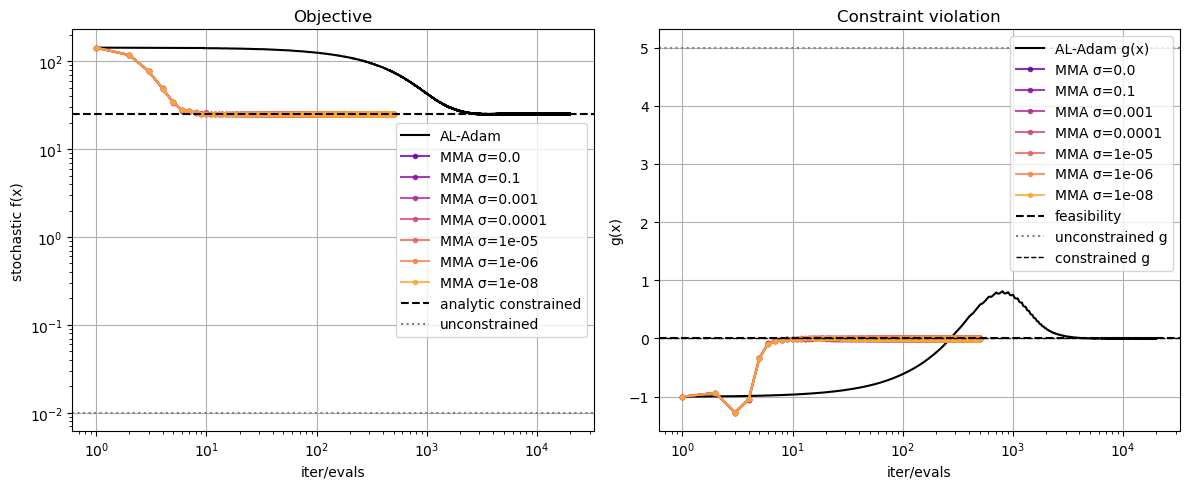

=== Running noise = 0.01, cond# = 100 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=10.6745, λ*=0.00817371
  E[f(x*)]=0.0215598 (noise const=0.00112555)
Unconstrained baseline: E[f(x_uncon)]= 0.00112555, g(x_uncon)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=0.0217178, g(x)=0.000961924, λ=0.00970985

MMA σ=0.0: res=5, ||x||=10.2, g(x)=-1.11e-06
MMA σ=0.1: res=5, ||x||=10, g(x)=-7.79e-07
MMA σ=0.001: res=5, ||x||=10, g(x)=-7.4e-05
MMA σ=0.0001: res=5, ||x||=10.1, g(x)=-2.68e-08
MMA σ=1e-05: res=5, ||x||=10.1, g(x)=-1.29e-10
MMA σ=1e-06: res=5, ||x||=9.98, g(x)=-2.18e-05
MMA σ=1e-08: res=5, ||x||=10.3, g(x)=-1.04e-09


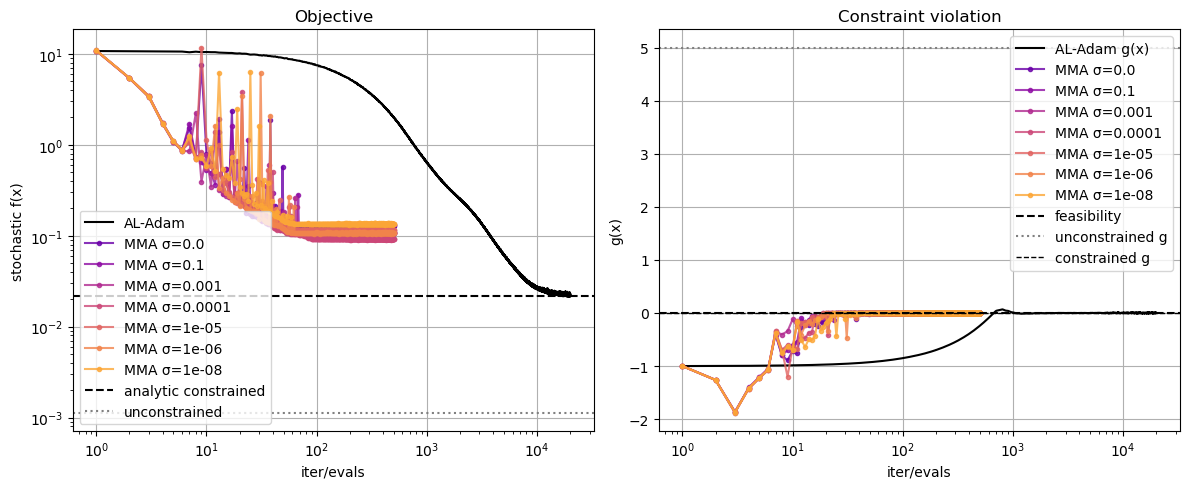

=== Running noise = 0.1, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=26 (noise const=1)
Unconstrained baseline: E[f(x_uncon)]= 1, g(x_uncon)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=25.1988, g(x)=-0.00427366, λ=9.99311

MMA σ=0.0: res=5, ||x||=5.11, g(x)=-0.00822
MMA σ=0.1: res=5, ||x||=5.09, g(x)=-0.000224
MMA σ=0.001: res=5, ||x||=5.05, g(x)=-0.00981
MMA σ=0.0001: res=5, ||x||=5.1, g(x)=-0.000367
MMA σ=1e-05: res=5, ||x||=5.06, g(x)=-1.38e-09
MMA σ=1e-06: res=5, ||x||=5.09, g(x)=-0.00329
MMA σ=1e-08: res=5, ||x||=5.09, g(x)=-0.0226


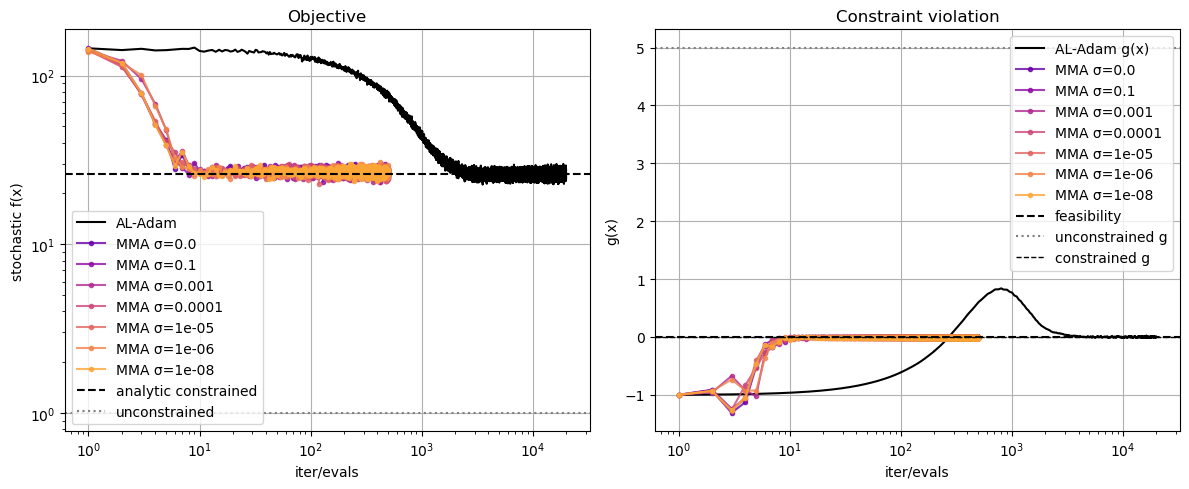

=== Running noise = 0.1, cond# = 100 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=10.6745, λ*=0.00817371
  E[f(x*)]=0.132989 (noise const=0.112555)
Unconstrained baseline: E[f(x_uncon)]= 0.112555, g(x_uncon)=5
Initial constraint g(x0)=-1 (init_feasible=True)

AL-Adam finished:
  last f_est=0.102699, g(x)=-0.00649519, λ=0.00805648

MMA σ=0.0: res=5, ||x||=10.8, g(x)=-0.71
MMA σ=0.1: res=5, ||x||=10.9, g(x)=-0.774
MMA σ=0.001: res=5, ||x||=11, g(x)=-0.836
MMA σ=0.0001: res=5, ||x||=10.7, g(x)=-0.621
MMA σ=1e-05: res=5, ||x||=10.6, g(x)=-0.495
MMA σ=1e-06: res=5, ||x||=10.8, g(x)=-0.652
MMA σ=1e-08: res=5, ||x||=10.9, g(x)=-0.876


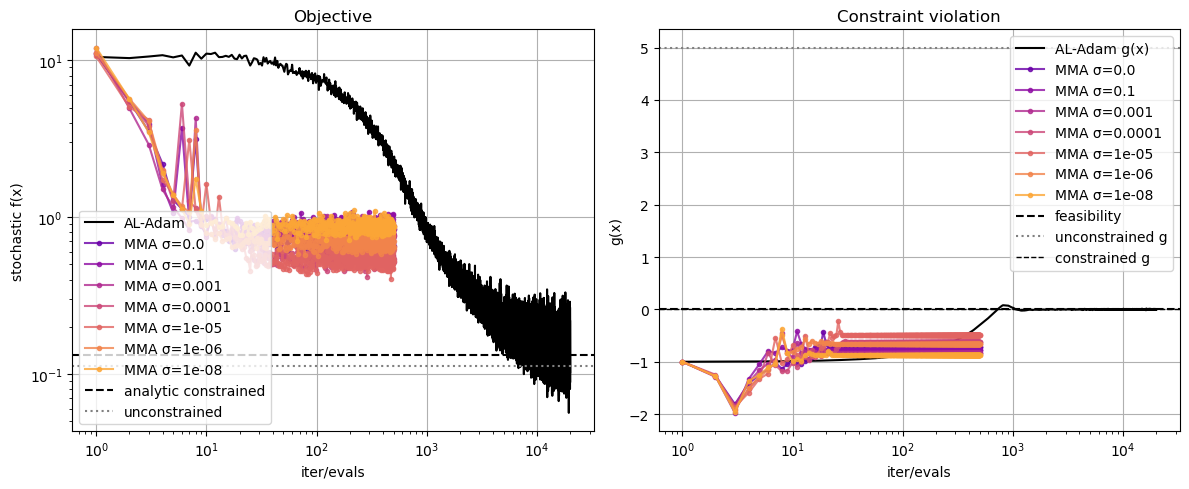

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt

# ---------------------------
# Helper: initialize x0 feasible or infeasible
# ---------------------------
def init_point(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = np.random.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            # shift into feasible region (make g <= 0)
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            # shift into infeasible region (make g > 0)
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0



def analytic_solution_expectation(A, c, b, noise):
    """
    Analytic solution of
        min_x  E[f(x,xi)] = ||A x||^2 + noise^2 tr(A^2)
        s.t.   c^T x - b <= 0
    Returns (x_star, lambda_star, active_flag, value_at_xstar, noise_const).
    """
    A2 = A.T @ A
    s = np.linalg.solve(A2, c)
    denom = float(c.dot(s))  # c^T (A^2)^{-1} c

    if b >= 0:
        # unconstrained minimizer x=0 feasible
        x_star = np.zeros_like(c)
        lambda_star = 0.0
        active = False
    else:
        # constraint active
        x_star = (b / denom) * s
        lambda_star = -2.0 * b / denom
        active = True

    const_term = (noise**2) * np.trace(A2)
    val = float(x_star.dot(A2.dot(x_star))) + const_term
    return x_star, lambda_star, active, val, const_term


def run_convex_stoch_det_constraint_exp(
    noise: float = 0.2,
    cond: int = 1,
    sigma_mins: list = [0.0, 0.01, 0.1],
    seed: int = 0,
    maxiters_adam: int = 20000,
    mma_maxeval: int = 2000,
    active_constraint = True,
    init_feasible: bool = False,
    # inner solver hyperparams:
    inner_kwargs = None,
    # outer AL hyperparams:
    rho: float = 1.0,
    lambda0: float = 0.0,
    tol_outer: float = 1e-6,
    rho_multiplier: float = 2.0,
    rho_update_max: int = 6,
    max_outer = 8,
    verbose: bool = True,
):
    np.random.seed(seed)
    n = 100
    A = np.eye(n) if cond==1 else randcond(n, cond)

    # random linear constraint
    c = np.random.randn(n)
    c /= np.linalg.norm(c)
    x_uncon = np.zeros(n)

    if active_constraint is None:
        b = np.random.uniform(-1, 1)
    elif active_constraint:
        b = np.dot(c, x_uncon) - 5
    else:
        b = np.dot(c, x_uncon) + 5

    print(f"Random constraint: ||c||={np.linalg.norm(c):.6g}, b={b:.6g}")

    # analytic expected optimum
    x_star, lambda_star, active, val_star, const_term = analytic_solution_expectation(A, c, b, noise)
    print("Analytic expected optimum (on expectation):")
    print(f"  active? {active}")
    print(f"  ||x*||={np.linalg.norm(x_star):.6g}, λ*={lambda_star:.6g}")
    print(f"  E[f(x*)]={val_star:.6g} (noise const={const_term:.6g})")

    val_uncon = const_term
    g_uncon = -b
    print(f"Unconstrained baseline: E[f(x_uncon)]= {val_uncon:.6g}, g(x_uncon)={g_uncon:.6g}")

    # stochastic helpers
    def sample_xi(): return np.random.randn(n) * noise
    def fgrad_stoch(x): return 2.0 * (A.T @ A @ (x + sample_xi()))
    def f_stoch_estimate(x): return float(np.linalg.norm(A.dot(x + sample_xi()))**2)
    def constraint_val(x): return float(np.dot(c, x) - b)

    # initial point (feasible or infeasible according to flag)
    x0 = init_point(n, c, b, force_feasible=init_feasible)
    print(f"Initial constraint g(x0)={constraint_val(x0):.6g} (init_feasible={init_feasible})")
    print()

    # inner kwargs defaults (if not provided)
    if inner_kwargs is None:
        inner_kwargs = {
            'alpha': 1e-3,
            'batch_size': 16,
            'patience': 10,
            'tol_step': 1e-5,
            'tol_g': 1e-4,
            'max_inner': None,     # None => rely on patience for stopping
            'verbose': False,
            'log_every': 200
        }

    # Run augmented Lagrangian (AL) with adam_inner
    

    x_al, lam_al, hist_al = adam_augmented_lagrangian(
    fgrad=fgrad_stoch,
    x0=x0.copy(),
    c=c,
    b=b,
    rho=rho,
    lambda0=lambda0,
    f_stoch_estimate=f_stoch_estimate,
    
    tol_outer=tol_outer,

    maxiters=maxiters_adam,
    
    rho_multiplier=rho_multiplier,
    
    rho_update_max=rho_update_max,
    
    inner_kwargs=inner_kwargs,   
    max_outer=max_outer,
    verbose=verbose
)

    print("AL-Adam finished:")
    last_f_est = hist_al['f_est'][-1] if len(hist_al['f_est']) > 0 else np.nan
    last_g = hist_al['g'][-1] if len(hist_al['g']) > 0 else constraint_val(x_al)
    print(f"  last f_est={last_f_est:.6g}, g(x)={last_g:.6g}, λ={lam_al:.6g}")
    print()

    # --- MMA comparison (unchanged logic) ---
    mma_results = []
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(sigma_mins)))

    for sigma_min, color in zip(sigma_mins, colors):
        opt = nlopt.opt(nlopt.LD_MMA, n)
        evals = 0.0
        mma_f_evals, mma_g_vals, mma_f_vals = [], [], []

        def f_and_grad_mma(x, grad):
            nonlocal evals, mma_f_evals, mma_g_vals, mma_f_vals
            xi = sample_xi()
            p = A.dot(x + xi)
            val = float(np.linalg.norm(p)**2)
            if grad.size > 0:
                grad[:] = 2.0 * (A.T.dot(p))
                evals += 1
                mma_f_evals.append(evals)
                mma_f_vals.append(val)
                mma_g_vals.append(constraint_val(x))
            else:
                evals += 0.5
            return val

        def cons_nl(x, grad):
            if grad.size > 0: grad[:] = c
            return float(c.dot(x) - b)

        opt.add_inequality_constraint(cons_nl, 1e-8)
        opt.set_min_objective(f_and_grad_mma)
        opt.set_maxeval(mma_maxeval)
        opt.set_param("sigma_min", float(sigma_min))

        x_mma = opt.optimize(x0.copy())
        res_code = opt.last_optimize_result()
        print(f"MMA σ={sigma_min}: res={res_code}, ||x||={np.linalg.norm(x_mma):.3g}, g(x)={constraint_val(x_mma):.3g}")
        mma_results.append((sigma_min, color, mma_f_evals, mma_g_vals, mma_f_vals))

    # --- plotting
    plt.figure(figsize=(12,5))

    # objective
    plt.subplot(1,2,1)
    plt.plot(hist_al['iter'], hist_al['f_est'], '-', color='black', label='AL-Adam')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, f_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    plt.axhline(val_star, color='k', linestyle='--', label='analytic constrained')
    plt.axhline(val_uncon, color='gray', linestyle=':', label='unconstrained')
    plt.xscale('log'); plt.yscale('log'); plt.legend(); plt.grid(True)
    plt.xlabel('iter/evals'); plt.ylabel('stochastic f(x)'); plt.title('Objective')

    # constraint
    plt.subplot(1,2,2)
    plt.plot(hist_al['iter'], hist_al['g'], '-', color='black', label='AL-Adam g(x)')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, g_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    plt.axhline(0, color='k', linestyle='--', label='feasibility')
    plt.axhline(g_uncon, color='gray', linestyle=':', label='unconstrained g')
    plt.axhline(constraint_val(x_star), color='k', linestyle='--', linewidth=1.0, label='constrained g')
    plt.xscale('log'); plt.legend(); plt.grid(True)
    plt.xlabel('iter/evals'); plt.ylabel('g(x)'); plt.title('Constraint violation')

    plt.tight_layout(); plt.show()

    return {
        "c": c, "b": b,
        "x_star": x_star, "val_star": val_star,
        "x_al": x_al, "lam_al": lam_al,
        "mma_results": mma_results,
        "val_uncon": val_uncon, "g_uncon": g_uncon,
        "hist_al": hist_al
    }





for noise in [0.01, 0.1]: #  0.1
    for cond in [1, 100]: # 100
        print("=== Running noise = {}, cond# = {} ===".format(noise, cond))
        res = run_convex_stoch_det_constraint_exp(noise=noise, cond=cond,
        sigma_mins=[0.0, 1e-1, 1e-3, 1e-4, 1e-5, 1e-6, 1e-8],
        seed=0,
        maxiters_adam=20000,
        mma_maxeval=500,
        active_constraint=True,
        init_feasible=False
        )
        


## Nonconvex analytical stochastic constrained optimization (general $a$ and random constraint $c$)

We consider the stochastic problem
$$
\min_{x\in\mathbb{R}^n} \; \mathbb{E}_{\xi}[\,f(x,\xi)\,] 
\qquad\text{s.t.}\qquad g(x)\equiv c^\top x - b \le 0,
$$
with
$$
f(x,\xi) = -\cos(a^\top (x+\xi)) + \tfrac{1}{2}\rho\,\|x\|^2,
$$
where $a\in\mathbb{R}^n$ is a fixed vector, $\xi\sim\mathcal N(0,\sigma^2 I)$, and $\rho>0$ is the Tikhonov regularizer.

---

Because $\xi$ is zero-mean Gaussian,
$$
\mathbb{E}_\xi\big[\cos(a^\top(x+\xi))\big] = \cos(a^\top x)\,\mathbb{E}_\xi[\cos(a^\top\xi)]
$$
(since $\mathbb{E}[\sin(a^\top\xi)]=0$). Also
$$
\mathbb{E}_\xi[\cos(a^\top\xi)] = \exp\!\Big(-\tfrac12\sigma^2\|a\|^2\Big).
$$
Define
$$
k := \exp\!\Big(-\tfrac12\sigma^2\|a\|^2\Big).
$$
Then the expected objective is
$$
F(x) = \mathbb{E}_\xi[f(x,\xi)] = -\,k\cos(a^\top x) + \tfrac{1}{2}\rho\|x\|^2.
$$

---

1. Inactive case. Compute the gradient
$$
\nabla_x F(x) = k\sin(a^\top x)\,a + \rho x.
$$
Set $\nabla_x F(x)=0$. For any $x$, decompose $x$ into its component parallel to $a$ and orthogonal part:
$$
u := \frac{a}{\|a\|}, \qquad x = s\,u + x_\perp,\quad u^\top x_\perp = 0.
$$
Project the stationarity condition onto the orthogonal complement of $a$:
$$
\rho x_\perp = 0 \quad\Longrightarrow\quad x_\perp = 0.
$$
Hence every stationary point must lie in the 1D subspace spanned by $a$:
$$
x = s\,u \quad\text{for some scalar } s\in\mathbb{R}.
$$
Insert $x = s u$ into the gradient equation. Since $a^\top x = \|a\| s$ and $a = \|a\| u$, we obtain the scalar stationarity equation
$$
\rho s + k\,\|a\| \,\sin(\|a\| s) = 0.
$$
Define the scalar function
$$
\varphi(s) := \rho s + k\,\|a\| \sin(\|a\| s).
$$
Every root $s=r$ of $\varphi(r)=0$ gives a stationary vector
$$
x^{(r)} = r\,u = \frac{r}{\|a\|} a.
$$
A stationary point $r$ is a local minimum if the second derivative (reduced scalar Hessian)
$$
\frac{d^2}{ds^2}\Big[-k\cos(\|a\| s) + \tfrac12 \rho s^2\Big] 
= k \|a\|^2 \cos(\|a\| s) + \rho
$$
is positive at $s=r$, i.e. $k\|a\|^2\cos(\|a\| r)+\rho>0$.

Practically we compute $k=\exp(-\tfrac12\sigma^2\|a\|^2)$ and $u=a/\|a\|$. We find roots of $\varphi(s)=\rho s + k\|a\| \sin(\|a\| s)=0$ on an interval using a root solver. Then for each root $r$ found we compute $F(x^{(r)})=-k\cos(\|a\| r)+\tfrac12\rho r^2$ and check second derivative sign to filter minima.

2. Inactive Case. When the unconstrained stationary points are not feasible ($c^\top x^{(r)}>b$ for all good minima), the constraint is active at the optimum. The KKT system for the expected problem is
$$
\nabla_x F(x) + \lambda c = 0, \qquad \lambda \ge 0,\qquad c^\top x = b.
$$
Substitute $\nabla_x F(x)= k\sin(a^\top x)\,a + \rho x$. The KKT system becomes
$$
\rho x + k\sin(a^\top x)\,a + \lambda c = 0,\qquad c^\top x = b.
$$

This is a coupled nonlinear system. It can be simplified by projecting onto the 2-dimensional subspace spanned by $a$ and $c$ (unless $c$ is collinear with $a$, in which case the reduction is 1-D): (...)


Practically we can:

1. Compute $u = a/\|a\|$ and its orthogonal component $r = c - (u^\top c) u$. If a and c are almost collinear then $\|r\|$ is small.
2. Set $w = r/\|r\|$ and reduce $x = s u + t w$.
3. Use a 1-D root solver scanning over an interval for $s$ to find all relevant roots.
5. For each root $s$ compute $\lambda$, then $t$ and finally $x$. Check feasibility and $\lambda\ge0$ and then compute the function and rank the roots.



Random a, c, chosen b=-2 (active=True)
Top 2 analytical candidates:
  #1 [inactive]: F=-0.995012, ||x||=0, g(x)=2
  #2 [active]: F=-0.974627, ||x||=2.02, g(x)=1.11e-15
AL-Adam optimum: F=-0.792948, ||x||=6.32, g(x)=0.00101
NLopt-MMA (σ=0.9) optimum: F=-0.577981, ||x||=8.86, g(x)=-0.0015
NLopt-MMA (σ=0.1) optimum: F=-0.462014, ||x||=10.3, g(x)=-0.0318
NLopt-MMA (σ=0.01) optimum: F=-0.413842, ||x||=10.7, g(x)=-9.27e-10
NLopt-MMA (σ=0.001) optimum: F=-0.311488, ||x||=11.5, g(x)=-0.00843
NLopt-MMA (σ=0.0001) optimum: F=-0.510417, ||x||=9.81, g(x)=-5.09e-08
NLopt-MMA (σ=0.0) optimum: F=-0.494241, ||x||=9.96, g(x)=6.86e-10


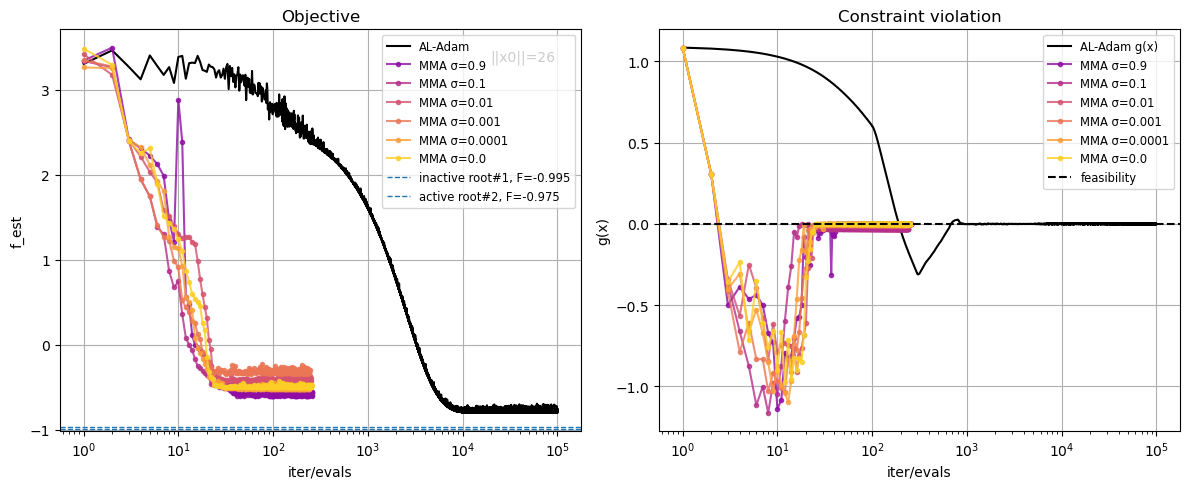

In [118]:

from scipy.optimize import brentq

def expected_objective(x, a, rho, k):
    return -k * np.cos(a.dot(x)) + 0.5 * rho * np.dot(x, x)


def find_inactive_roots(rho, k, a, xmin=-50, xmax=50, step=0.5):
    norm_a = np.linalg.norm(a)
    phi = lambda s: rho * s + k * norm_a * np.sin(norm_a * s)
    xs = np.arange(xmin, xmax, step)
    roots = []
    for xL, xR in zip(xs[:-1], xs[1:]):
        fL, fR = phi(xL), phi(xR)
        if fL == 0:
            roots.append(xL)
        elif fL * fR < 0:
            try:
                r = brentq(phi, xL, xR, maxiter=200, xtol=1e-12)
                roots.append(r)
            except Exception:
                pass
    roots = np.array(sorted(set(np.round(roots, 12))))
    # map roots to x in R^n
    u = a / norm_a
    candidates = []
    for r in roots:
        x = r * u
        val = expected_objective(x, a, rho, k)
        candidates.append((x, val, 'inactive'))
    return candidates

# active constrained roots 
def find_active_roots(rho, k, a, c, b, xmin=-50, xmax=50, step=0.5):
    norm_a = np.linalg.norm(a)
    u = a / norm_a
    rvec = c - (u @ c) * u
    if np.linalg.norm(rvec) < 1e-12:
        
        s = b / (c @ u)
        x = s * u
        val = expected_objective(x, a, rho, k)
        return [(x, val, 'active-collinear')]
    w = rvec / np.linalg.norm(rvec)

    cu, cw = c @ u, c @ w
    def Phi(s):
        lam = rho * (s * cu - b) / (cw**2)
        return rho * s + k * norm_a * np.sin(norm_a * s) + lam * cu

    roots = []
    xs = np.arange(xmin, xmax, step)
    for xL, xR in zip(xs[:-1], xs[1:]):
        fL, fR = Phi(xL), Phi(xR)
        if np.isnan(fL) or np.isnan(fR):
            continue
        if fL == 0:
            roots.append(xL)
        elif fL * fR < 0:
            try:
                r = brentq(Phi, xL, xR, maxiter=200, xtol=1e-12)
                roots.append(r)
            except Exception:
                pass
    roots = np.array(sorted(set(np.round(roots, 12))))
    candidates = []
    for s in roots:
        lam = rho * (s * cu - b) / (cw**2)
        t = -lam * cw / rho
        x = s * u + t * w
        val = expected_objective(x, a, rho, k)
        candidates.append((x, val, 'active'))
    return candidates

def run_nonconvex_stoch_det_constraint(
        noise=0.2, reg=0.5, sigma_mins=[0.0, 1e-3, 1e-2],
        seed=0, maxiters_adam=5000, mma_maxeval=200,
        root_search_range=50, root_step=0.5, show_topk=5,
        active_constraint=None):  
    np.random.seed(seed)
    n = 100

    # random a and c
    a = np.random.randn(n); a /= np.linalg.norm(a)
    c = np.random.randn(n); c /= np.linalg.norm(c)

    # analytical candidates first, to know unconstrained minimizers
    k = np.exp(-noise**2 / 2.0)
    inactive = find_inactive_roots(reg, k, a,
                                   xmin=-root_search_range,
                                   xmax=root_search_range,
                                   step=root_step)
    inactive_sorted = sorted(inactive, key=lambda t: t[1])
    x_uncon, val_uncon, _ = inactive_sorted[0] if inactive_sorted else (np.zeros(n), 0.0, 'none')

    # choose b depending on desired constraint activity
    if active_constraint is None:
        b = np.random.uniform(-1, 1)  # random
    elif active_constraint:  
        
        b = np.dot(c, x_uncon) - 2
    else: 
       
        b = np.dot(c, x_uncon) + 2

    print(f"Random a, c, chosen b={b:.3g} (active={active_constraint})")

    def sample_xi(): return np.random.randn(n) * noise
    def fgrad_stoch(x):
        xi = sample_xi(); z = a.dot(x + xi)
        return np.sin(z) * a + reg * x
    def f_stoch_estimate(x):
        xi = sample_xi(); z = a.dot(x + xi)
        return -np.cos(z) + 0.5 * reg * np.dot(x, x)
    def constraint_val(x): return float(np.dot(c, x) - b)

    # random initial point (ensure infeasible)
    x0 = np.random.randn(n) * (1 + np.random.rand() * 5)  #* 10.0
    if constraint_val(x0) <= 0:
        delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
        x0 = x0 + delta
    x0norm = np.linalg.norm(x0)

    # recompute candidates (inactive + active)
    active = find_active_roots(reg, k, a, c, b,
                               xmin=-root_search_range,
                               xmax=root_search_range,
                               step=root_step)
    all_candidates = inactive + active
    all_candidates = sorted(all_candidates, key=lambda t: t[1])[:show_topk]

    print(f"Top {len(all_candidates)} analytical candidates:")
    for i,(x,val,typ) in enumerate(all_candidates,1):
        print(f"  #{i} [{typ}]: F={val:.6g}, ||x||={np.linalg.norm(x):.3g}, g(x)={constraint_val(x):.3g}")

    # AL-Adam 
 
    x_al, lam_al, hist_al = adam_augmented_lagrangian(
    fgrad=fgrad_stoch,
    x0=x0.copy(),
    c=c,
    b=b,
    rho=1.0,
    lambda0=0.0,
    f_stoch_estimate=f_stoch_estimate,
    
    tol_outer=None,

    maxiters=maxiters_adam,
    
    rho_multiplier=None,
    
    rho_update_max=None,
    
    inner_kwargs=None,   
    max_outer=None,
    verbose=None
)

    # compute expected objective at the AL-Adam solution using local variables
    k = np.exp(-noise**2 / 2.0)
    val_al = expected_objective(x_al, a, reg, k)
    print(f"AL-Adam optimum: F={val_al:.6g}, ||x||={np.linalg.norm(x_al):.3g}, g(x)={constraint_val(x_al):.3g}")


    # --- NLopt-MMA baselines ---
    mma_results = []
    colors = make_red_colors(len(sigma_mins))
    for sigma_min, color in zip(sigma_mins, colors):
        try:
            opt = nlopt.opt(nlopt.LD_MMA, n)
        except Exception as e:
            print("NLopt-MMA not available:", e)
            break

        evals = 0.0
        mma_f_evals, mma_g_vals, mma_f_vals = [], [], []
        def f_and_grad_mma(x, grad):
            nonlocal evals, mma_f_evals, mma_g_vals, mma_f_vals
            x = np.asarray(x)
            xi_local = np.random.randn(n) * noise
            z = a.dot(x + xi_local)
            val = -np.cos(z) + 0.5 * reg * np.dot(x, x)
            if grad.size > 0:
                grad[:] = np.sin(z) * a + reg * x
                evals += 1
                mma_f_evals.append(evals)
                mma_f_vals.append(val)
                mma_g_vals.append(constraint_val(x))
            return val

        def cons_nl(x, grad):
            if grad.size > 0: grad[:] = c
            return float(np.dot(c, x) - b)

        opt.add_inequality_constraint(cons_nl, 1e-8)
        opt.set_min_objective(f_and_grad_mma)
        opt.set_maxeval(mma_maxeval)
        opt.set_param("sigma_min", float(sigma_min))
        opt.set_param("inner_gradients", 0)
        opt.set_param("always_improve", 0)
        opt.set_param("inner_maxeval", 5)

        x_mma = opt.optimize(x0.copy())
        res_code = opt.last_optimize_result()
        val_mma = expected_objective(x_mma, a, reg, k)
        print(f"NLopt-MMA (σ={sigma_min}) optimum: F={val_mma:.6g}, ||x||={np.linalg.norm(x_mma):.3g}, g(x)={constraint_val(x_mma):.3g}")


        mma_results.append((sigma_min, color, mma_f_evals, mma_g_vals, mma_f_vals))

    # plotting
    plt.figure(figsize=(12,5))
    # objective
    plt.subplot(1,2,1)
    plt.plot(hist_al['iter'], hist_al['f_est'], '-', color='black', label='AL-Adam')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, f_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    for i,(x,val,typ) in enumerate(all_candidates,1):
        plt.axhline(val, linestyle='--', linewidth=1.0,
                    label=f'{typ} root#{i}, F={val:.3g}')
    plt.xscale('log'); plt.legend(fontsize='small'); plt.grid(True); #plt.yscale('log'); 
    plt.title('Objective'); plt.xlabel('iter/evals'); plt.ylabel('f_est')
    plt.gca().text(0.95,0.95,f'||x0||={x0norm:.3g}',transform=plt.gca().transAxes,ha='right',va='top')

    # constraint
    plt.subplot(1,2,2)
    plt.plot(hist_al['iter'], hist_al['g'], '-', color='black', label='AL-Adam g(x)')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, g_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    plt.axhline(0, color='k', linestyle='--', label='feasibility')
    plt.legend(fontsize='small'); plt.grid(True); plt.xscale('log')
    plt.title('Constraint violation'); plt.xlabel('iter/evals'); plt.ylabel('g(x)')
    plt.tight_layout(); plt.show()

    return {
        'c': c, 'b': b, 'a': a,
        'x_al': x_al, 'lam_al': lam_al, 'hist_al': hist_al,
        'topk': all_candidates, 'x0norm': x0norm,
        'mma_results': mma_results
    }

res = run_nonconvex_stoch_det_constraint(
    noise=0.1,
    reg=0.01,
    sigma_mins=[0.9, 1e-1, 1e-2, 1e-3, 1e-4, 0.0], # 1e-5, 1e-6
    seed=42,
    maxiters_adam=100000,
    mma_maxeval=500,
    root_search_range=50,
    root_step=0.5,
    show_topk=2,
    active_constraint=True
)


If we make the constraint stochastic then there is an issue related to the respect of this constraint. MMA fails because of it

Random a, c, chosen b=-2 (active=True)
Top 2 analytical candidates:
  #1 [inactive]: F=-1, ||x||=0, g(x)=2
  #2 [active]: F=-0.593606, ||x||=2.01, g(x)=-1.69e-07
AL-Adam optimum: F=-0.589397, ||x||=2.02, g(x)=-0.0103
NLopt-MMA (σ=0.0) optimum: F=-0.593606, ||x||=2.01, g(x)=3.73e-07
NLopt-MMA (σ=0.001) optimum: F=1.11577e+57, ||x||=1.06e+29, g(x)=-8.98e+28
NLopt-MMA (σ=0.01) optimum: F=-0.593606, ||x||=2.01, g(x)=3.83e-07


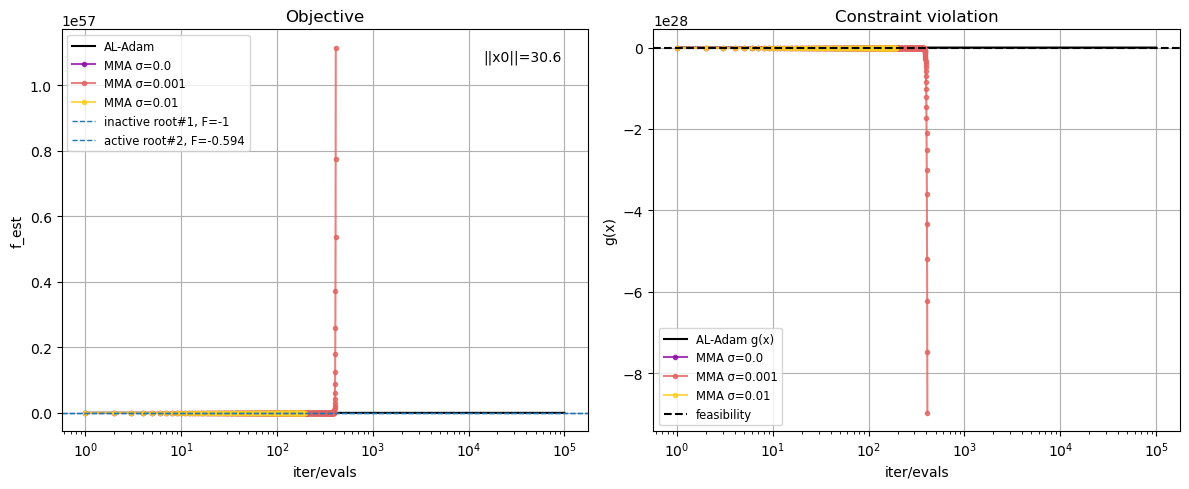

In [117]:

def run_nonconvex_stoch_det_constraint(
        noise=0.2, reg=0.5, sigma_mins=[0.0, 1e-3, 1e-2],
        seed=0, maxiters_adam=5000, mma_maxeval=200,
        root_search_range=50, root_step=0.5, show_topk=5,
        active_constraint=None):  
    np.random.seed(seed)
    n = 100

    # random a and c
    a = np.random.randn(n); a /= np.linalg.norm(a)
    c = np.random.randn(n); c /= np.linalg.norm(c)

    k = np.exp(-noise**2 / 2.0)
    inactive = find_inactive_roots(reg, k, a,
                                   xmin=-root_search_range,
                                   xmax=root_search_range,
                                   step=root_step)
    inactive_sorted = sorted(inactive, key=lambda t: t[1])
    x_uncon, val_uncon, _ = inactive_sorted[0] if inactive_sorted else (np.zeros(n), 0.0, 'none')

    if active_constraint is None:
        b = np.random.uniform(-1, 1)
    elif active_constraint:
        b = np.dot(c, x_uncon) - 2
    else:
        b = np.dot(c, x_uncon) + 2

    print(f"Random a, c, chosen b={b:.3g} (active={active_constraint})")

    def sample_xi(): return np.random.randn(n) * noise
    def fgrad_stoch(x):
        xi = sample_xi(); z = a.dot(x + xi)
        return np.sin(z) * a + reg * x
    def f_stoch_estimate(x):
        xi = sample_xi(); z = a.dot(x + xi)
        return -np.cos(z) + 0.5 * reg * np.dot(x, x)
    def constraint_val(x):
        xi = sample_xi()
        return float(np.dot(c, x + xi) - b)  # stochastic constraint

    x0 = np.random.randn(n) * (1 + np.random.rand() * 5)  
    if constraint_val(x0) <= 0:
        delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
        x0 = x0 + delta
    x0norm = np.linalg.norm(x0)

    active = find_active_roots(reg, k, a, c, b,
                               xmin=-root_search_range,
                               xmax=root_search_range,
                               step=root_step)
    all_candidates = inactive + active
    all_candidates = sorted(all_candidates, key=lambda t: t[1])[:show_topk]

    print(f"Top {len(all_candidates)} analytical candidates:")
    for i,(x,val,typ) in enumerate(all_candidates,1):
        print(f"  #{i} [{typ}]: F={val:.6g}, ||x||={np.linalg.norm(x):.3g}, g(x)={constraint_val(x):.3g}")

    x_al, lam_al, hist_al = adam_augmented_lagrangian(
        fgrad=fgrad_stoch, x0=x0.copy(), c=c, b=b,
        rho=50.0, lambda0=0.0, alpha=1e-3,
        maxiters=maxiters_adam, update_lambda_every=1, log_every=1,
        f_stoch_estimate=f_stoch_estimate,
        rho_multiplier=1.1, rho_update_freq=2000,
    )

    val_al = expected_objective(x_al, a, reg, k)
    print(f"AL-Adam optimum: F={val_al:.6g}, ||x||={np.linalg.norm(x_al):.3g}, g(x)={constraint_val(x_al):.3g}")

    # --- NLopt-MMA ---
    mma_results = []
    colors = make_red_colors(len(sigma_mins))
    for sigma_min, color in zip(sigma_mins, colors):
        try:
            opt = nlopt.opt(nlopt.LD_MMA, n)
        except Exception as e:
            print("NLopt-MMA not available:", e)
            break

        evals = 0.0
        mma_f_evals, mma_g_vals, mma_f_vals = [], [], []

        def f_and_grad_mma(x, grad):
            nonlocal evals, mma_f_evals, mma_g_vals, mma_f_vals
            x = np.asarray(x)
            xi_local = np.random.randn(n) * noise
            z = a.dot(x + xi_local)
            val = -np.cos(z) + 0.5 * reg * np.dot(x, x)
            if grad.size > 0:
                grad[:] = np.sin(z) * a + reg * x
                evals += 1
                mma_f_evals.append(evals)
                mma_f_vals.append(val)
                mma_g_vals.append(constraint_val(x))
            return val

        def cons_nl(x, grad):
            xi_local = np.random.randn(n) * noise
            if grad.size > 0: grad[:] = c
            return float(np.dot(c, x + xi_local) - b)

        opt.add_inequality_constraint(cons_nl, 1e-8)
        opt.set_min_objective(f_and_grad_mma)
        opt.set_maxeval(mma_maxeval)
        opt.set_param("sigma_min", float(sigma_min))
        opt.set_param("inner_gradients", 0)
        opt.set_param("always_improve", 0)
        opt.set_param("inner_maxeval", 5)

        x_mma = opt.optimize(x0.copy())
        val_mma = expected_objective(x_mma, a, reg, k)
        print(f"NLopt-MMA (σ={sigma_min}) optimum: F={val_mma:.6g}, ||x||={np.linalg.norm(x_mma):.3g}, g(x)={constraint_val(x_mma):.3g}")

        mma_results.append((sigma_min, color, mma_f_evals, mma_g_vals, mma_f_vals))

    # --- Plotting ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(hist_al['iter'], hist_al['f_est'], '-', color='black', label='AL-Adam')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, f_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    for i,(x,val,typ) in enumerate(all_candidates,1):
        plt.axhline(val, linestyle='--', linewidth=1.0,
                    label=f'{typ} root#{i}, F={val:.3g}')
    plt.xscale('log'); plt.legend(fontsize='small'); plt.grid(True)
    plt.title('Objective'); plt.xlabel('iter/evals'); plt.ylabel('f_est')
    plt.gca().text(0.95,0.95,f'||x0||={x0norm:.3g}',transform=plt.gca().transAxes,ha='right',va='top')

    plt.subplot(1,2,2)
    plt.plot(hist_al['iter'], hist_al['g'], '-', color='black', label='AL-Adam g(x)')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        plt.plot(f_evals, g_vals, '.-', color=color, alpha=0.8, label=f'MMA σ={sigma_min}')
    plt.axhline(0, color='k', linestyle='--', label='feasibility')
    plt.legend(fontsize='small'); plt.grid(True); plt.xscale('log')
    plt.title('Constraint violation'); plt.xlabel('iter/evals'); plt.ylabel('g(x)')
    plt.tight_layout(); plt.show()

    return {
        'c': c, 'b': b, 'a': a,
        'x_al': x_al, 'lam_al': lam_al, 'hist_al': hist_al,
        'topk': all_candidates, 'x0norm': x0norm,
        'mma_results': mma_results
    }


res = run_nonconvex_stoch_det_constraint(
    noise=0.000001, 
    reg=0.2,
    sigma_mins=[0.0, 1e-3, 1e-2],
    seed=4,
    maxiters_adam=100000,
    mma_maxeval=500,
    root_search_range=50,
    root_step=0.5,
    show_topk=2,
    active_constraint=True
)
